---
title: "Лабораторна робота №5. Кластеризація текстових даних"
description: "Технології аналізу текстової інформації та машинне навчання | КрНУ ім. М. Остроградського"
author: "&copy; Роменський В'ячеслав"
date: today
format:
  html:
    toc: true
    toc-depth: 4
    toc-location: right
    code-fold: false
    code-tools: true
    embed-resources: true
    smooth-scroll: true
jupyter: python3
---


## Мета роботи

Опанувати базові підходи до *кластеризації текстових документів*: побудову *TF-IDF*-представлення корпусу, застосування *k-means* та *агломеративної кластеризації*, а також інтерпретацію кластерів на основі характерних термінів і візуалізації документів.


## Постановка завдання

Потрібно сформувати *навчальний корпус документів* і виконати для нього такі кроки:

1. підготувати корпус до кластерного аналізу;
2. виконати базове очищення текстів;
3. побудувати *TF-IDF*-матрицю;
4. застосувати *k-means*;
5. інтерпретувати кластери через топ-слова;
6. візуалізувати документи у зниженому просторі ознак;
7. побудувати *агломеративну кластеризацію*;
8. побудувати *дендрограму*;
9. порівняти результати двох підходів;
10. оцінити вибір кількості кластерів і зробити змістовні висновки.


In [68]:
# Базові імпорти
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram


## 1. Формування корпусів

In [69]:
base_corpus = [
    "машинне навчання дозволяє аналізувати великі корпуси текстових даних і будувати моделі класифікації",
    "аналіз тексту включає токенізацію векторизацію tf idf класифікацію та кластеризацію документів",
    "обробка природної мови спирається на статистичні моделі латентні представлення та семантичний аналіз",
    "моніторинг соціальних медіа передбачає збирання повідомлень виявлення тем і аналіз тональності",
    "чатові дискусії можуть містити ботів тролів координацію повідомлень і інформаційні атаки",
    "аналітика соціальних мереж включає виявлення аномальної активності аналіз коментарів і сегментацію авторів",
    "футбольна команда провела інтенсивне тренування і покращила точність передач та швидкість атаки",
    "тренер проаналізував тактику гри фізичну форму спортсменів та результати останніх матчів",
    "спортсмени виконують вправи на витривалість силу координацію та відновлення після навантаження"
]

base_df = pd.DataFrame({
    "doc_id": [f"D{i+1}" for i in range(len(base_corpus))],
    "text": base_corpus
})

csv_path = Path("data\\lab5_variant2_science_education_analytics.csv")

if csv_path.exists():
    loaded_df = pd.read_csv(csv_path)
    corpus_df = pd.concat([base_df, loaded_df], ignore_index=True)
else:
    print(f"Файл {csv_path} не знайдено.")

display(corpus_df)
print("Завантажено документів:", len(corpus_df))

,doc_id,text
0,D1,машинне навчання дозволяє аналізувати великі к...
1,D2,аналіз тексту включає токенізацію векторизацію...
2,D3,обробка природної мови спирається на статистич...
3,D4,моніторинг соціальних медіа передбачає збиранн...
4,D5,чатові дискусії можуть містити ботів тролів ко...
5,D6,аналітика соціальних мереж включає виявлення а...
6,D7,футбольна команда провела інтенсивне тренуванн...
7,D8,тренер проаналізував тактику гри фізичну форму...
8,D9,спортсмени виконують вправи на витривалість си...
9,V2_1,наукова стаття описує експериментальне дослідж...


Завантажено документів: 21


## 2. Базове очищення тексту

Виконаємо очищення, токенізацію, фільтрацію, стемінг.


In [91]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = text.replace("’", "'").replace("`", "'")
    text = re.sub(r"[-_/]", " ", text)
    text = re.sub(r"[^\w\sіїєґІЇЄҐ']", " ", text, flags=re.UNICODE)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"_+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text: str) -> list[str]:
    return [token for token in text.split() if len(token) >= 2]

def remove_stopwords(tokens: list[str]) -> list[str]:
    return [token for token in tokens if token not in uk_stopwords]

def simple_stem(word: str) -> list[str]:
    suffixes = ["ують","ого","ими","ами","ями","ів","ий","ою","ів","ів","их","ує","яє","ії","ія","ію","ає","о","а","у","і","е","и"]
    for suf in suffixes:
        if word.endswith(suf):
            return word[:-len(suf)]
    return word

def list_stem(tokens: list[str]) -> list[str]:
    return [simple_stem(token) for token in tokens]

uk_stopwords = {
    "і", "й", "та", "а", "але", "або", "що", "це", "у", "в", "до", "на", "за",
    "із", "з", "як", "для", "не", "по", "про", "при", "від", "над", "під",
    "то", "же", "чи", "його", "її", "їх", "бути",
    "між", "тому", "тоді", "ж"
}

corpus_df["clean_text"] = corpus_df["text"].apply(clean_text)
corpus_df["tokens"] = corpus_df["clean_text"].apply(tokenize)
corpus_df["filtered_tokens"] = corpus_df["tokens"].apply(remove_stopwords)
corpus_df["stem_tokens"] = corpus_df["filtered_tokens"].apply(list_stem)

corpus_df[["doc_id", "filtered_tokens"]]

print("Після очистки:")
display(corpus_df[["doc_id", "clean_text"]].head())

print("Після токенізації:")
display(corpus_df[["doc_id", "tokens"]].head())

print("Після фільтрації:")
display(corpus_df[["doc_id", "filtered_tokens"]].head())

print("Після стемінгу:")
display(corpus_df[["doc_id", "stem_tokens"]].head())

analysis_df = corpus_df.copy()
analysis_df["analysis_text"] = analysis_df["stem_tokens"].apply(" ".join)

Після очистки:


,doc_id,clean_text
0,D1,машинне навчання дозволяє аналізувати великі к...
1,D2,аналіз тексту включає токенізацію векторизацію...
2,D3,обробка природної мови спирається на статистич...
3,D4,моніторинг соціальних медіа передбачає збиранн...
4,D5,чатові дискусії можуть містити ботів тролів ко...


Після токенізації:


,doc_id,tokens
0,D1,"[машинне, навчання, дозволяє, аналізувати, вел..."
1,D2,"[аналіз, тексту, включає, токенізацію, вектори..."
2,D3,"[обробка, природної, мови, спирається, на, ста..."
3,D4,"[моніторинг, соціальних, медіа, передбачає, зб..."
4,D5,"[чатові, дискусії, можуть, містити, ботів, тро..."


Після фільтрації:


,doc_id,filtered_tokens
0,D1,"[машинне, навчання, дозволяє, аналізувати, вел..."
1,D2,"[аналіз, тексту, включає, токенізацію, вектори..."
2,D3,"[обробка, природної, мови, спирається, статист..."
3,D4,"[моніторинг, соціальних, медіа, передбачає, зб..."
4,D5,"[чатові, дискусії, можуть, містити, ботів, тро..."


Після стемінгу:


,doc_id,stem_tokens
0,D1,"[машинн, навчання, дозвол, аналізуват, велик, ..."
1,D2,"[аналіз, текст, включ, токенізац, векторизац, ..."
2,D3,"[обробк, природної, мов, спирається, статистич..."
3,D4,"[моніторинг, соціальн, меді, передбач, збиранн..."
4,D5,"[чатов, дискус, можуть, містит, бот, трол, коо..."


## 3. Побудова TF-IDF-матриці

Тепер перетворимо корпус у матрицю *документ–термін* у схемі *TF-IDF*.  
Саме це подання буде використано для подальшої кластеризації.

Для навчального прикладу встановимо:

- `min_df=1`, щоб зберегти всі слова з корпусу;
- `ngram_range=(1, 1)`, тобто використовуємо лише окремі слова.


In [92]:
vectorizer = TfidfVectorizer(min_df=1, ngram_range=(1, 1))
X = vectorizer.fit_transform(analysis_df["analysis_text"])

print("Форма TF-IDF-матриці:", X.shape)

tfidf_df = pd.DataFrame(
    X.toarray(),
    index=corpus_df["doc_id"],
    columns=vectorizer.get_feature_names_out()
)

tfidf_df.iloc[:5, :10].round(3)

Форма TF-IDF-матриці: (21, 155)


,idf,nlp,python,tf,автоматичн,автор,активност,аналіз,аналізуват,аналітик
doc_id,,,,,,,,,,
D1,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.301,0.0
D2,0.359,0.0,0.0,0.359,0.0,0.0,0.0,0.227,0.000,0.0
D3,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.215,0.000,0.0
D4,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.222,0.000,0.0
D5,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.000,0.0


## 4. Матриця подібності документів

Перед кластеризацією корисно подивитися, які документи вже на рівні *TF-IDF* виглядають ближчими один до одного.  
Для цього побудуємо матрицю *косинусної подібності*.


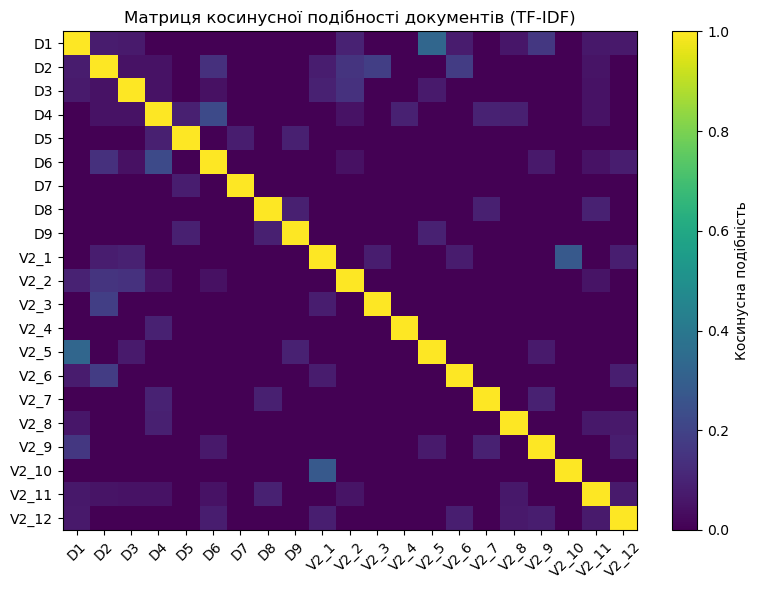

In [94]:
cosine_similarity_matrix = (X * X.T).toarray()

similarity_df = pd.DataFrame(
    cosine_similarity_matrix,
    index=corpus_df["doc_id"],
    columns=corpus_df["doc_id"]
)

plt.figure(figsize=(8, 6))
plt.imshow(similarity_df.values, aspect="auto")
plt.colorbar(label="Косинусна подібність")
plt.xticks(range(len(similarity_df.columns)), similarity_df.columns, rotation=45)
plt.yticks(range(len(similarity_df.index)), similarity_df.index)
plt.title("Матриця косинусної подібності документів (TF-IDF)")
plt.tight_layout()
plt.show()

## 5. Застосування k-means

In [95]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

kmeans_df = corpus_df[["doc_id", "text"]].copy()
kmeans_df["cluster_kmeans"] = kmeans_labels
kmeans_df = kmeans_df.sort_values(["cluster_kmeans", "doc_id"]).reset_index(drop=True)

kmeans_df


,doc_id,text,cluster_kmeans
0,D5,чатові дискусії можуть містити ботів тролів ко...,0
1,D7,футбольна команда провела інтенсивне тренуванн...,0
2,D8,тренер проаналізував тактику гри фізичну форму...,0
3,D9,спортсмени виконують вправи на витривалість си...,0
4,V2_11,навчальний курс розвиває компетентності з анал...,0
5,V2_12,аналітики інтегрують дані з різних джерел для ...,0
6,V2_4,освітня програма передбачає лекції лабораторні...,0
7,V2_7,аналітична платформа формує дашборди для моніт...,0
8,V2_8,цифровий інструмент обєднує збирання даних віз...,0
9,V2_1,наукова стаття описує експериментальне дослідж...,1


## 6. Найхарактерніші терміни кластерів k-means

Щоб зрозуміти зміст кожного кластера, знайдемо слова з найбільшими вагами в координатах центрів кластерів.


In [96]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort(axis=1)[:, ::-1]

for cluster_id in range(kmeans.n_clusters):
    top_terms = [terms[ind] for ind in order_centroids[cluster_id, :7]]
    print(f"Кластер {cluster_id}: {', '.join(top_terms)}")


Кластер 0: дан, результат, координац, спортсмен, форм, атак, джерел
Кластер 1: дослідження, науков, опис, присвячен, коректном, експеримент, методик
Кластер 2: аналіз, кластеризац, документ, векторизац, включ, соціальн, виявлення
Кластер 3: модел, будуват, машинн, навчання, аналізуват, дозвол, велик


## 7. Візуалізація документів у двовимірному просторі

Для графічної інтерпретації застосуємо *TruncatedSVD* і зведемо багатовимірний простір *TF-IDF* до двох координат.  
Це не змінює сам факт кластеризації, але дозволяє наочно побачити взаємне розташування документів.


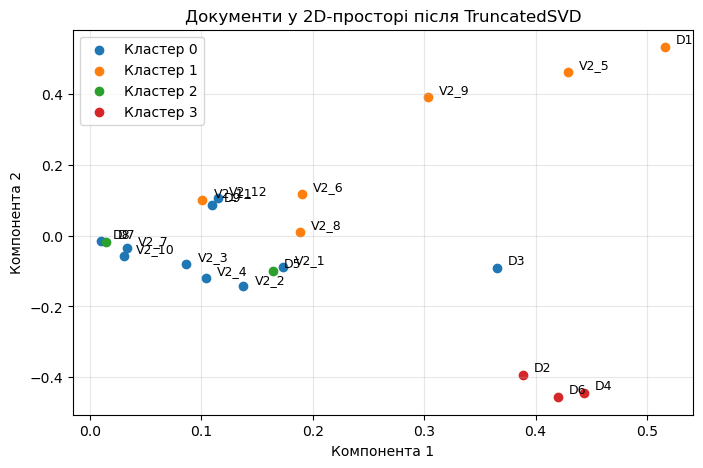

In [84]:
svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd_2d.fit_transform(X)

plot_df = pd.DataFrame({
    "doc_id": corpus_df["doc_id"],
    "x": X_2d[:, 0],
    "y": X_2d[:, 1],
    "cluster_kmeans": kmeans_labels
})

plt.figure(figsize=(8, 5))
for cluster_id in sorted(plot_df["cluster_kmeans"].unique()):
    cluster_points = plot_df[plot_df["cluster_kmeans"] == cluster_id]
    plt.scatter(cluster_points["x"], cluster_points["y"], label=f"Кластер {cluster_id}")

for _, row in plot_df.iterrows():
    plt.text(row["x"] + 0.01, row["y"] + 0.01, row["doc_id"], fontsize=9)

plt.title("Документи у 2D-просторі після TruncatedSVD")
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Порівняння результатів k-means та агломеративної кластеризації

Номери кластерів у різних алгоритмах можуть не збігатися буквально, але нас цікавить *які документи групуються разом*.


In [85]:
aggl = AgglomerativeClustering(n_clusters=4, metric="euclidean", linkage="ward")
aggl_labels = aggl.fit_predict(X.toarray())

aggl_df = corpus_df[["doc_id", "text"]].copy()
aggl_df["cluster_agglomerative"] = aggl_labels
aggl_df = aggl_df.sort_values(["cluster_agglomerative", "doc_id"]).reset_index(drop=True)

comparison_df = corpus_df[["doc_id", "text"]].copy()
comparison_df["cluster_kmeans"] = kmeans_labels
comparison_df["cluster_agglomerative"] = aggl_labels

comparison_df.sort_values(["cluster_kmeans", "cluster_agglomerative", "doc_id"]).reset_index(drop=True)


,doc_id,text,cluster_kmeans,cluster_agglomerative
0,D3,обробка природної мови спирається на статистич...,0,0
1,V2_2,дослідники аналізують корпус документів та пер...,0,0
2,V2_3,університетська лабораторія готує публікацію п...,0,0
3,V2_1,наукова стаття описує експериментальне дослідж...,0,1
4,V2_10,науковий семінар присвячено відтворюваності ек...,0,1
5,V2_12,аналітики інтегрують дані з різних джерел для ...,0,1
6,D8,тренер проаналізував тактику гри фізичну форму...,0,2
7,D9,спортсмени виконують вправи на витривалість си...,0,2
8,V2_4,освітня програма передбачає лекції лабораторні...,0,2
9,V2_7,аналітична платформа формує дашборди для моніт...,0,2


## 9. Побудова дендрограми

Дендрограма показує, у якій послідовності документи та групи документів об'єднуються між собою.  
Чим менша висота об'єднання, тим ближчими є відповідні документи або кластери.


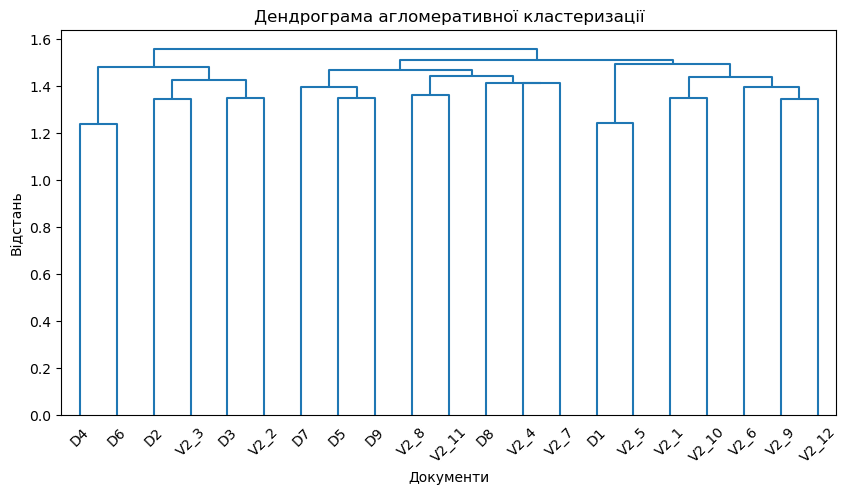

In [86]:
Z = linkage(X.toarray(), method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=corpus_df["doc_id"].tolist())
plt.title("Дендрограма агломеративної кластеризації")
plt.xlabel("Документи")
plt.ylabel("Відстань")
plt.grid(False)
plt.show()


## 10. Оцінка через silhouette score

За silhouette score видно, що і справді кращий варіант k = 4.

In [87]:
silhouette_results = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_results.append({"k": k, "silhouette_score": score})

silhouette_df = pd.DataFrame(silhouette_results)
silhouette_df


,k,silhouette_score
0,2,0.008843
1,3,0.010066
2,4,0.012909
3,5,0.016160
4,6,0.016035
5,7,0.019231
6,8,0.018678
7,9,0.020607


## 11. Кластеризація після зниження розмірності

In [100]:
svd_latent = TruncatedSVD(n_components=4, random_state=42)
X_lsa = svd_latent.fit_transform(X)

kmeans_lsa = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_lsa = kmeans_lsa.fit_predict(X_lsa)

lsa_cluster_df = corpus_df[["doc_id", "text"]].copy()
lsa_cluster_df["cluster_after_svd"] = labels_lsa
lsa_cluster_df.sort_values(["cluster_after_svd", "doc_id"]).reset_index(drop=True)

c:\Users\suziu\.conda\envs\slavaDs\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,doc_id,text,cluster_after_svd
0,D1,машинне навчання дозволяє аналізувати великі к...,0
1,V2_5,студенти виконують практичні завдання з python...,0
2,V2_9,система бізнес аналітики допомагає аналізувати...,0
3,D2,аналіз тексту включає токенізацію векторизацію...,1
4,D3,обробка природної мови спирається на статистич...,1
5,V2_2,дослідники аналізують корпус документів та пер...,1
6,V2_3,університетська лабораторія готує публікацію п...,1
7,V2_6,викладач пояснює теоретичні основи векторизаці...,1
8,D4,моніторинг соціальних медіа передбачає збиранн...,2
9,D5,чатові дискусії можуть містити ботів тролів ко...,2


## 12. Коротка інтерпретація результатів

За k-means ми побачили, що 4 кластери, які було виявлено, це:
1. Через "координацію" теми соцмедіа і спорту об'єднались у один кластер. (дані, результат, координацію, спортсмен, форма, атака, побудова)
2. Тема освіти. (опис, науковий, дослідження, семінар, методик, присвячений, коректний)
3. Аналіз тексту, кластеризація. (аналіз, кластеризацію, документ, соціальний, виявлення, включає, текст)
4. Машинне навчання, моделювання. (модель, будувати, класифікації, навчання, машиння, аналізуват, основа)
В основному кластери вийшли схожими на справжній розподіл тем, але через малу кількість даних співпадіння одного рідкого слова може намертво об'єднати абсолютно дві різні теми в одну, як це сталось із документами, в яких наявне слово "координація".
Результати для k-means та агломеративної кластеризації виявились дуже різними, але в даному випадку розподіл за агломеративною кластеризацією був кращим. Також за агломеративною кластеризацією можна побачити чітко, які документи були об'єднані на якому етапі.
Вибір 4 кластерів було обрано за найвищим silhouette score.
Для такої малої кількості даних структура кластерів стала ще гіршою більше зменшення розмірності.

## Висновки

У ході лабораторної роботи було:

- сформовано навчальний корпус документів;
- виконано базове очищення текстів;
- побудовано *TF-IDF*-матрицю;
- застосовано *k-means* і проінтерпретовано кластери через топ-слова;
- виконано *агломеративну кластеризацію* і побудовано *дендрограму*;
- оцінено доцільну кількість кластерів за допомогою *методу ліктя* та *silhouette score*;
- продемонстровано зв'язок кластеризації із зниженням розмірності.

У результаті було показано, що кластеризація є важливим інструментом *навчання без учителя* для виявлення внутрішньої структури текстового корпусу.


## Контрольні питання

1. У чому полягає задача кластеризації текстових документів?
Задача кластеризації текстових документів полягає в автоматичному групуванні схожих документів без попередньо заданих міток класів.
2. Чому перед кластеризацією текст потрібно векторизувати?
Перед кластеризацією текст потрібно векторизувати, бо алгоритми працюють із числовими ознаками, а не з текстовими рядками.
3. Яка роль *TF-IDF* у кластерному аналізі тексту?
TF-IDF допомагає виділити важливі слова документа та зменшити вплив занадто частих термінів у кластерному аналізі.
4. У чому відмінність між *k-means* та *агломеративною кластеризацією*?
K-means ділить документи на наперед задану кількість кластерів за центроїдами, а агломеративна кластеризація поступово об’єднує найближчі об’єкти в ієрархічну структуру.
5. Як інтерпретувати кластер через топ-терміни?
Кластер інтерпретують через топ-терміни як набір найхарактерніших слів, що описують спільну тематику документів у групі.
6. Що показує дендрограма?
Дендрограма показує ієрархію об’єднання об’єктів або кластерів та відстані між ними.
7. Для чого використовується *метод ліктя*?
Метод ліктя використовується для вибору оптимальної кількості кластерів за зміною внутрішньокластерної помилки.
8. Що означає *silhouette score*?
Silhouette score показує, наскільки добре об’єкти належать своєму кластеру порівняно з іншими кластерами.
9. Чому зниження розмірності може впливати на кластеризацію?
Зниження розмірності може впливати на кластеризацію, бо прибирає шум і корельовані ознаки або навпаки втрачає корисну інформацію.
10. Яке практичне значення кластеризації має для аналізу текстів і соціальних медіа?
Практичне значення кластеризації полягає у виявленні тем, сегментації аудиторії та аналізі великих масивів текстів і соціальних медіа.
